# **Aggregation Analysis and Trends:** 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [3]:
data= pd.read_csv("data.csv")
data.shape

(42468, 14)

In [4]:
data.head(2)

,age,workclass,education,education-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,salary
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K


### **1. Average Hours per Week by Country:**

Objective: Check if people in some countries work more than others.
How: Group by native-country and calculate mean hours-per-week.

In [5]:
data.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'gender', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'salary'],
      dtype='object')

In [6]:
dass= data.groupby(by= "native-country")["hours-per-week"].mean().reset_index().sort_values(by= "hours-per-week", ascending= False)
dass

,native-country,hours-per-week
11,Greece,46.897959
37,Thailand,44.700000
19,Iran,42.949153
35,South,42.852174
9,France,42.789474
20,Ireland,42.638889
23,Japan,42.282609
32,Portugal,42.238806
0,Cambodia,42.035714
8,England,41.937008


In [7]:
dass.head(4)

,native-country,hours-per-week
11,Greece,46.897959
37,Thailand,44.700000
19,Iran,42.949153
35,South,42.852174


**Peoples from countries having longest work weeks (top 10):**

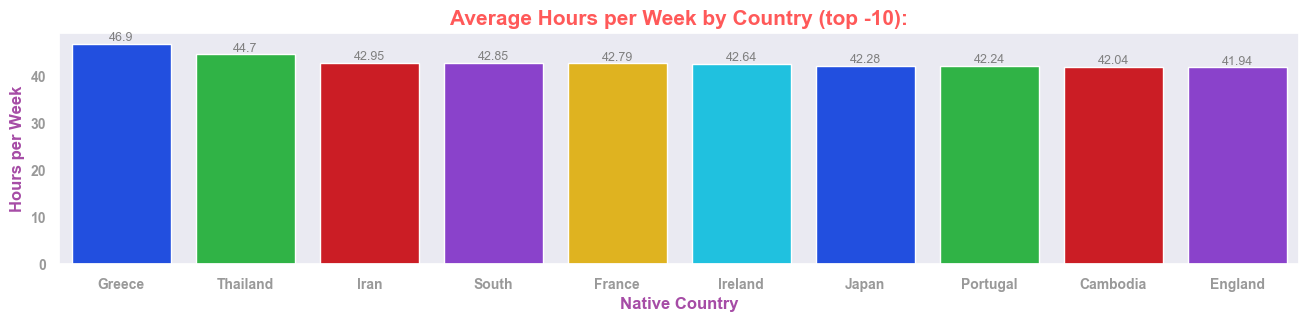

In [8]:
dassi= dass.head(10)
plt.figure(figsize= (16, 3))
sns.set_theme(style= "dark", context= "notebook")
sns.barplot(x= dassi["native-country"], y= dassi["hours-per-week"], palette= "bright6")
# add annotations
for i in range(len(dassi)):
    plt.text(x= i, y= dassi["hours-per-week"].iloc[i], s= dassi["hours-per-week"].iloc[i].round(2), ha= "center", va= "bottom", color= "gray", fontsize= 9) 

plt.title("Average Hours per Week by Country (top -10):", fontsize= 15, fontweight= "bold", color= "red", alpha= 0.65)
plt.xlabel("Native Country", fontsize= 12, fontweight= "bold", color= "purple", alpha= 0.7)
plt.ylabel("Hours per Week", fontsize= 12, fontweight= "bold", color= "purple", alpha= 0.7)
plt.xticks(color= "gray", fontsize= 10, fontweight= "bold", alpha= 0.8)
plt.yticks(color= "gray", fontsize= 10, fontweight= "bold", alpha= 0.8)
plt.show()

* Greece has the highest average weekly work hours.

* European countries dominate the top 10 most working countries.

* Asian countries like Thailand and Japan show high work hours.

* Work hour differences among countries are relatively small.

* Developed and developing countries show similar work patterns.

* Top five countries exceed 42.5 hours weekly on average.

* Greece stands out with significantly higher work hours.

* Western countries like France and England work fewer hours.

* There's a narrow range between most countries' work hours.

* Cultural or economic factors may drive these work patterns.

**Contries havaing lowest work-weeks (10 countries):**

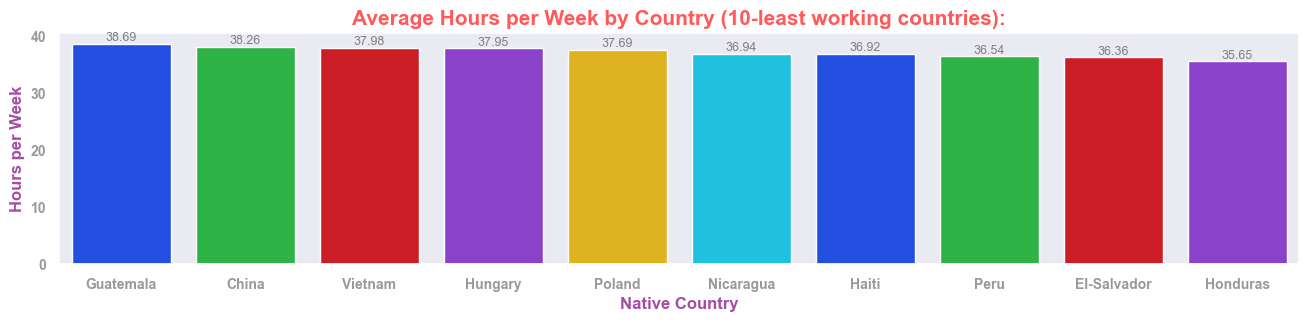

In [9]:
daio= dass.tail(10)
plt.figure(figsize= (16, 3))
sns.set_theme(style= "dark", context= "notebook")
sns.barplot(x= daio["native-country"], y= daio["hours-per-week"], palette= "bright6")
# add annotations
for i in range(len(daio)):
    plt.text(x= i, y= daio["hours-per-week"].iloc[i], s= daio["hours-per-week"].iloc[i].round(2), ha= "center", va= "bottom", color= "gray", fontsize= 9) 

plt.title("Average Hours per Week by Country (10-least working countries):", fontsize= 15, fontweight= "bold", color= "red", alpha= 0.65)
plt.xlabel("Native Country", fontsize= 12, fontweight= "bold", color= "purple", alpha= 0.7)
plt.ylabel("Hours per Week", fontsize= 12, fontweight= "bold", color= "purple", alpha= 0.7)
plt.xticks(color= "gray", fontsize= 10, fontweight= "bold", alpha= 0.8)
plt.yticks(color= "gray", fontsize= 10, fontweight= "bold", alpha= 0.8)
plt.show()

* Honduras has the lowest average weekly work hours overall.

* All countries in this group work under 39 hours weekly.

* Work hour differences are narrow across these 10 countries.

* Central American countries dominate the least-working list.

* Eastern Europe also appears with Hungary and Poland included.

* China and Vietnam have relatively low average work hours.

* No Western European countries are among the least-working.

* The gap from `highest (Greece)` to `lowest (Honduras)` is `\~11 hours` whic is more than 2 hrs per day in difference considering 5-days work week. 

----
----
----
-----
----

### **2. Income by Country and Gender:**

In [10]:
data.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'gender', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'salary'],
      dtype='object')

In [11]:
data.head(3)

,age,workclass,education,education-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,salary
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K


In [12]:
asx= data[["native-country", "gender", "salary"]].value_counts().reset_index()
asx.shape

(160, 4)

In [13]:
data["native-country"].nunique()

42

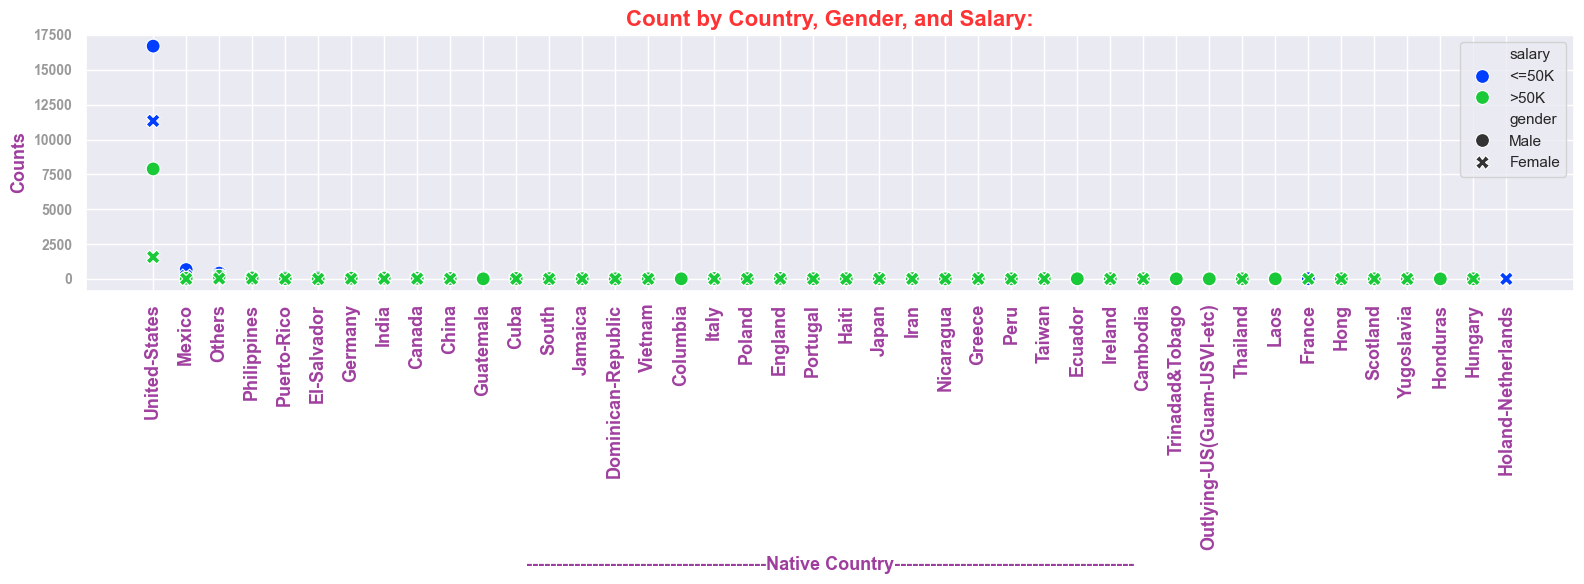

In [14]:
sns.set_theme(style="darkgrid", context="notebook", palette="bright6")

plt.figure(figsize=(16, 6))
sns.scatterplot(
    data=asx,
    x="native-country", # first variable (country)
    y="count",          # second variable (people count)
    hue="salary",       # third variable (color)
    style="gender",     # fourth variable (marker shape)
    s=100               # size of points
)
plt.xticks(rotation=90, fontsize= 13, fontweight= "bold", color= "purple", alpha= 0.75)
plt.title("Count by Country, Gender, and Salary:", fontsize= 16, color= "red", fontweight= 'bold', alpha= 0.8)
plt.yticks(color= "gray", fontsize= 10, fontweight= "bold", alpha= 0.8)
plt.ylabel("Counts", color= "purple", alpha= 0.76, fontsize= 13, fontweight= "bold")
plt.xlabel("----------------------------------------Native Country----------------------------------------", color= "purple", alpha= 0.76, fontsize= 13, fontweight= "bold")
plt.tight_layout()
plt.show()

<Figure size 1800x600 with 0 Axes>

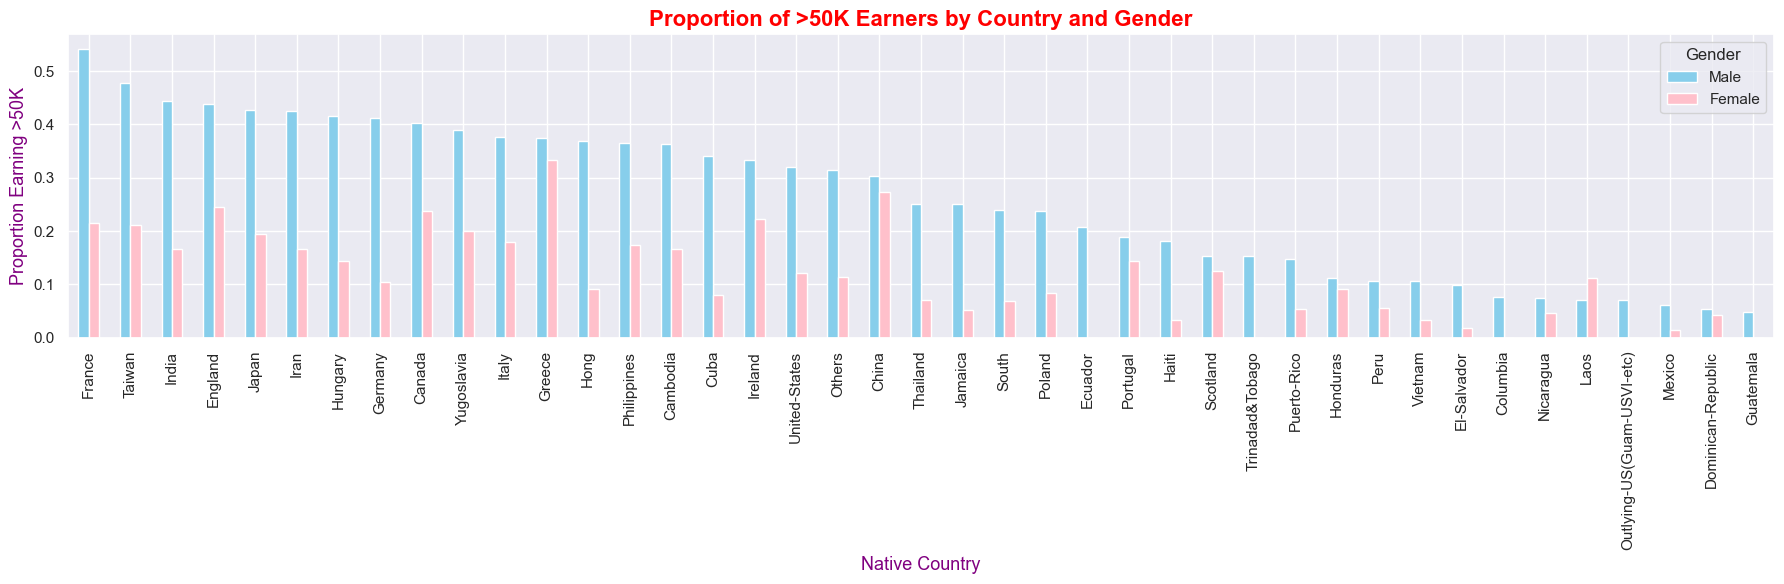

In [15]:
# Group by country and gender, calculate percentage earning >50K
income_gender_country = (
    data.groupby(['native-country', 'gender'])['salary']
    .value_counts(normalize=True)
    .rename('proportion')
    .reset_index()
    .query("salary == '>50K'")
    .pivot(index='native-country', columns='gender', values='proportion')
    .fillna(0)
)

income_gender_country = income_gender_country.sort_values(by=['Male', 'Female'], ascending=False)
income_gender_country.head(10)  # Show top 10 for preview

# Plotting gender pay gap by country
plt.figure(figsize=(18, 6))
income_gender_country[['Male', 'Female']].plot(kind='bar', figsize=(18,6), color=['skyblue', 'pink'])
plt.title("Proportion of >50K Earners by Country and Gender", fontsize=16, fontweight='bold', color='red')
plt.ylabel("Proportion Earning >50K", fontsize=13, color='purple')
plt.xlabel("Native Country", fontsize=13, color='purple')
plt.xticks(rotation=90, fontsize=11)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

<Figure size 1800x600 with 0 Axes>

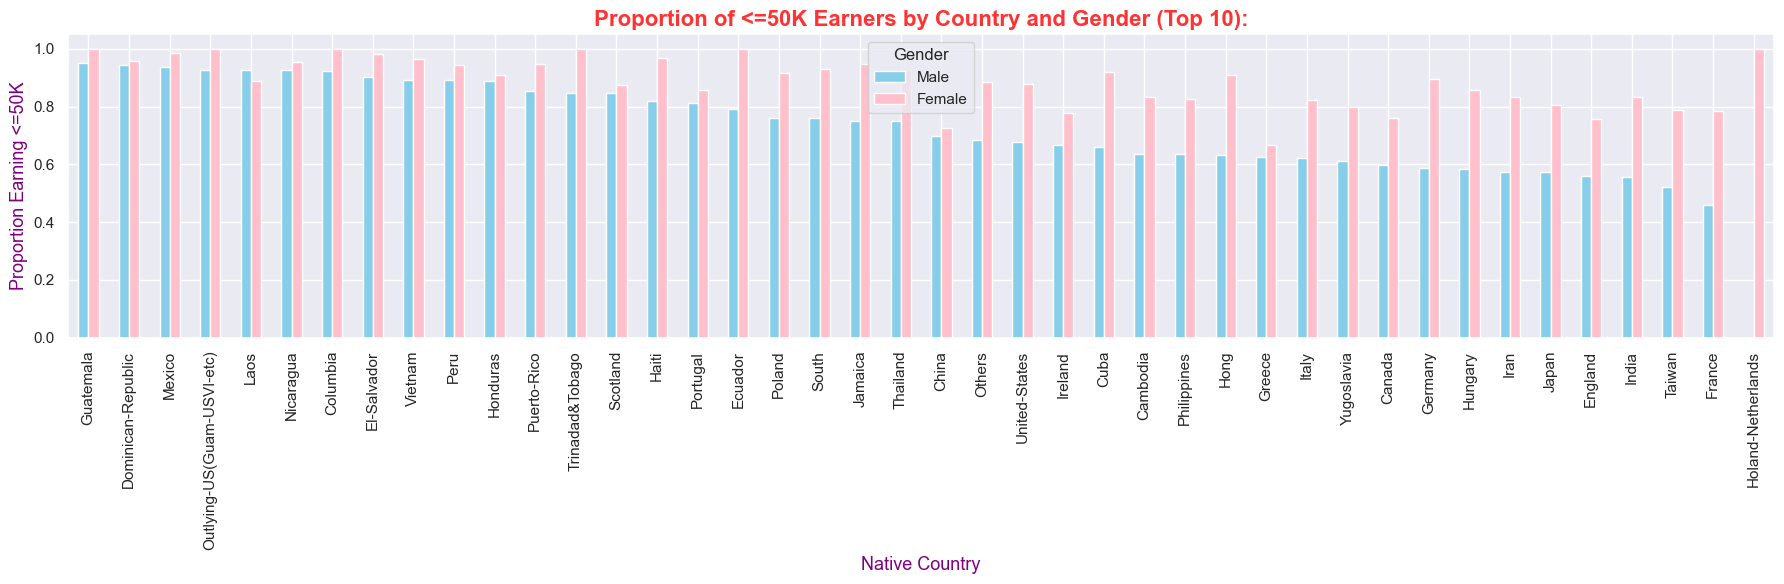

In [20]:
# Group by country and gender, calculate percentage earning <=50K
income_gender_country = (
    data.groupby(['native-country', 'gender'])['salary']
    .value_counts(normalize=True)
    .rename('proportion')
    .reset_index()
    .query("salary == '<=50K'")
    .pivot(index='native-country', columns='gender', values='proportion')
    .fillna(0)
)

income_gender_country = income_gender_country.sort_values(by=['Male', 'Female'], ascending=False)
income_gender_country.head(10)  # Show top 10 for preview

# Plotting gender pay gap by country
plt.figure(figsize=(18, 6))
income_gender_country[['Male', 'Female']].plot(kind='bar', figsize=(18,6), color=['skyblue', 'pink'])
plt.title("Proportion of <=50K Earners by Country and Gender (Top 10):", fontsize=16, fontweight='bold', color='red', alpha= 0.8)
plt.ylabel("Proportion Earning <=50K", fontsize=13, color='purple')
plt.xlabel("Native Country", fontsize=13, color='purple')
plt.xticks(rotation=90, fontsize=11)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

- Heavy U.S. dominance in the dataset

- Clear salary and gender separation

- Sparse representation from most non-U.S. countries

* United States has highest individual count

* Most U.S. individuals earn <=50K

* Males dominate high-count countries

* Mexico has second-highest individual count

* Most Mexicans earn <=50K

* Other countries have low individual counts

* High earners spread across many countries

* Few females earn >50K

* U.S. females mostly earn <=50K

* Gender imbalance visible in many countries

* Income imbalance highest in United States

* Countries sorted left to right alphabetically

---
-----
-----
----
----

### **3. Top 5 Occupations by Salary Class:**

Objective: Find top earning and low earning job roles.
How: Rank occupations by proportion of >50K earners.

In [22]:
data.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'gender', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'salary'],
      dtype='object')

In [27]:
data["occupation"].nunique()

15

In [34]:
app= data.groupby(by= 'salary')["occupation"].value_counts().reset_index()
app.head(3)

,salary,occupation,count
0,<=50K,Other-service,4163
1,<=50K,Adm-clerical,4093
2,<=50K,Craft-repair,3622


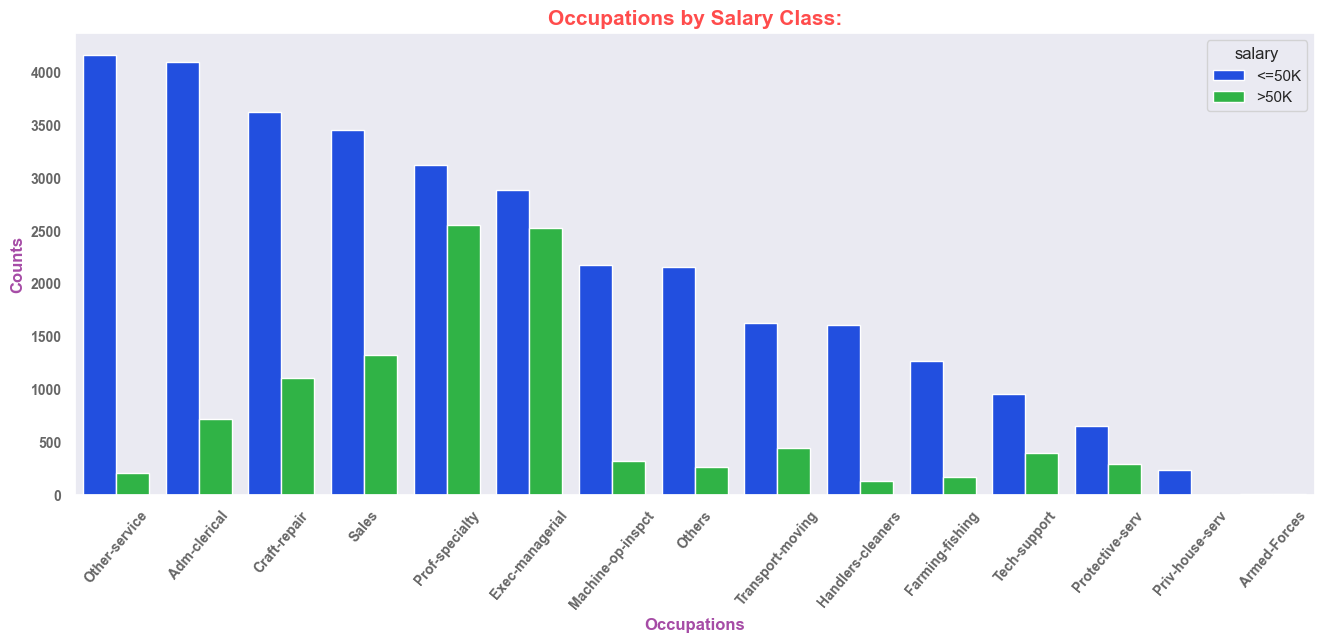

In [52]:
plt.figure(figsize= (16, 6))
sns.set_theme(style= "dark", context= "notebook")
sns.barplot(data= app, x= "occupation", y= "count", hue= "salary", palette= 'bright6', )
plt.xlabel("Occupations", fontsize= 12, fontweight= "bold", color= "purple", alpha= 0.7)
plt.ylabel("Counts", fontsize= 12, fontweight= "bold", color= "purple", alpha= 0.7) 
plt.title("Occupations by Salary Class:", color= "red", fontsize= 15, fontweight= "bold", alpha= 0.7)
plt.xticks(rotation= 50, fontsize= 10, fontweight= "bold", color= "black", alpha= 0.6)
plt.yticks(color= "black", fontsize= 10, fontweight= "bold", alpha= 0.6)
plt.show()

Two professional occupations `prof-speciality` and `exec-managerial` have the higest number of `>50k` earners than any others. 

**Top earning job roles:**

1. **Top earners of different occupations from `<=50K` salary group:**

In [66]:
app[app["salary"] == "<=50K"].sort_values(by= "count", ascending= False).head(10)

,salary,occupation,count
0,<=50K,Other-service,4163
1,<=50K,Adm-clerical,4093
2,<=50K,Craft-repair,3622
3,<=50K,Sales,3447
4,<=50K,Prof-specialty,3123
5,<=50K,Exec-managerial,2883
6,<=50K,Machine-op-inspct,2172
7,<=50K,Others,2160
8,<=50K,Transport-moving,1628
9,<=50K,Handlers-cleaners,1610


2. **Lowest earners of different occupations from `<=50K` salary group:**

In [67]:
app[app["salary"] == "<=50K"].sort_values(by= "count", ascending= False).tail(10)

,salary,occupation,count
5,<=50K,Exec-managerial,2883
6,<=50K,Machine-op-inspct,2172
7,<=50K,Others,2160
8,<=50K,Transport-moving,1628
9,<=50K,Handlers-cleaners,1610
10,<=50K,Farming-fishing,1263
11,<=50K,Tech-support,958
12,<=50K,Protective-serv,651
13,<=50K,Priv-house-serv,237
14,<=50K,Armed-Forces,10


3. **Top earners of different occupations from `>50K` salary group:**

In [68]:
app[app["salary"] == ">50K"].sort_values(by= "count", ascending= False).head(10)

,salary,occupation,count
15,>50K,Prof-specialty,2556
16,>50K,Exec-managerial,2529
17,>50K,Sales,1319
18,>50K,Craft-repair,1104
19,>50K,Adm-clerical,720
20,>50K,Transport-moving,443
21,>50K,Tech-support,393
22,>50K,Machine-op-inspct,320
23,>50K,Protective-serv,293
24,>50K,Others,261


4. **Lowest earners of different occupations from `>50K` salary group:**

In [69]:
app[app["salary"] == ">50K"].sort_values(by= "count", ascending= False).tail(10)

,salary,occupation,count
20,>50K,Transport-moving,443
21,>50K,Tech-support,393
22,>50K,Machine-op-inspct,320
23,>50K,Protective-serv,293
24,>50K,Others,261
25,>50K,Other-service,203
26,>50K,Farming-fishing,171
27,>50K,Handlers-cleaners,128
28,>50K,Armed-Forces,5
29,>50K,Priv-house-serv,3


* Most "Other-service" earn ≤50K, few earn >50K

* "Adm-clerical" jobs mostly pay ≤50K

* "Craft-repair" has moderate >50K earners

* "Sales" shows more ≤50K than >50K earners

* "Prof-specialty" has many in both salary classes

* "Exec-managerial" has high >50K representation

* "Machine-op-inspect" mostly earn ≤50K

* "Others" category dominated by ≤50K earners

* "Transport-moving" mostly ≤50K, fewer >50K

* "Handlers-cleaners" overwhelmingly ≤50K

* "Farming-fishing" has very few high earners

* "Tech-support" has some >50K earners

* "Protective-serv" low in both salary classes

* "Priv-house-serv" mostly earn ≤50K

* "Armed-Forces" has very few total entries

---
-----
---
----
----
----

#### **4. Education and Capital Loss:**

Objective: See if less-educated people incur more losses.
How: Group by education, calculate average capital-loss.

In [85]:
gps= (data[["education", "capital-loss"]])
dfg= gps.groupby(by= "education")["capital-loss"].mean(numeric_only=True).round(2).reset_index().sort_values(by= "capital-loss", ascending= False)
dfg

,education,capital-loss
10,Doctorate,238.85
14,Prof-school,238.64
12,Masters,172.50
9,Bachelors,140.83
7,Assoc-acdm,92.78
15,Some-college,87.28
11,HS-grad,83.45
8,Assoc-voc,76.42
4,5th-6th,66.36
5,7th-8th,61.21


We get very small values for capital loss, this is happening because, the dataset for `capital-gain` and `capital-loss` columns are mostly sparse but, in averaging, all these values contribute to `n` but have no contribution to the `sum`.

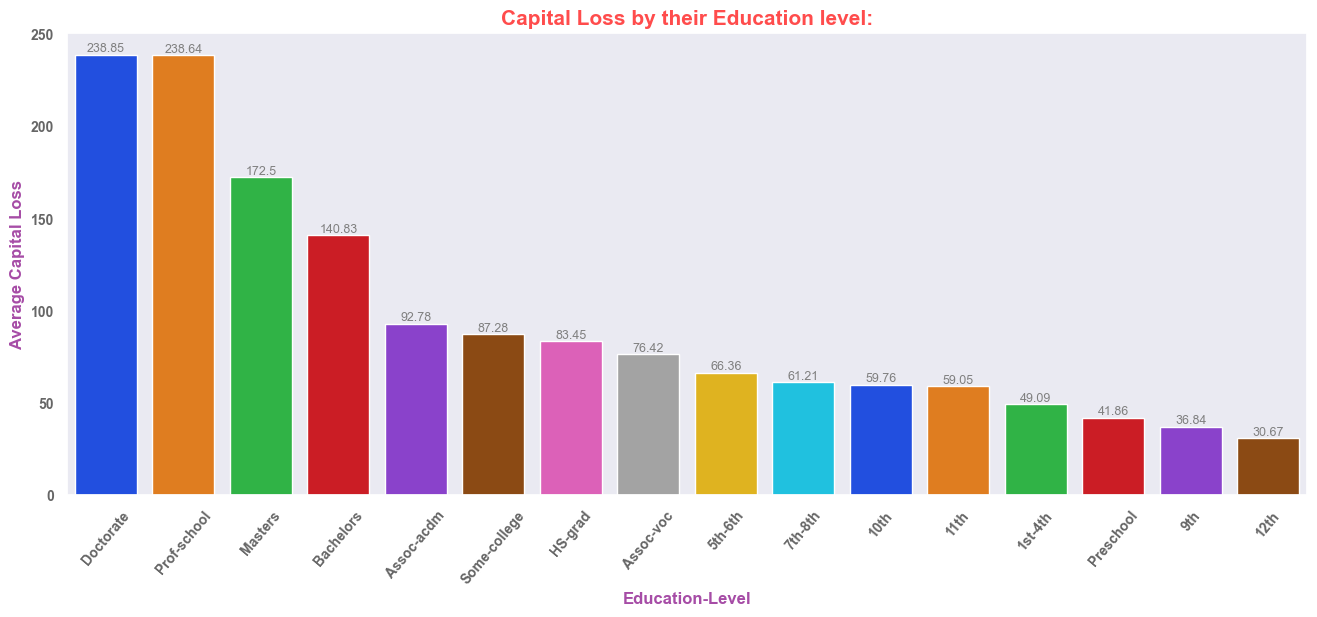

In [82]:
plt.figure(figsize= (16, 6))
sns.set_theme(style= "dark", context= "notebook")
sns.barplot(data= dfg, x= "education", y= "capital-loss", palette="bright", hue= "education", legend= False)
plt.xlabel("Education-Level", fontsize= 12, fontweight= "bold", color= "purple", alpha= 0.7)
plt.ylabel("Average Capital Loss", fontsize= 12, fontweight= "bold", color= "purple", alpha= 0.7)
plt.title("Capital Loss by their Education level:", color= "red", fontsize= 15, fontweight= "bold", alpha= 0.7)
plt.xticks(rotation= 50, fontsize= 10, fontweight= "bold", color= "black", alpha= 0.6)
plt.yticks(color= "black", fontsize= 10, fontweight= "bold", alpha= 0.6)
#add annotations
for i in range(len(dfg)):
    plt.text(x= i, y= dfg["capital-loss"].iloc[i], s= dfg["capital-loss"].iloc[i].round(2), ha= "center", va= "bottom", color= "gray", fontsize= 9) 
plt.show()

• Doctorate and Prof-school show highest capital loss (~239)
• Masters level experiences significant loss (172.5)
• Bachelors degree shows moderate impact (140.83)
• Associate degree and some-college cluster around 85-95
• High school graduation shows 83.45 loss
• Elementary levels (1st-12th grade) demonstrate lowest losses
• Educational attainment correlates with capital loss magnitude
• Higher education levels face greater financial vulnerability
• Professional degrees particularly affected by losses
• Clear inverse relationship between education and financial stability